Load and prepare model

In [10]:
import pandas as pd
from pathlib import Path

# Get the current directory
current_dir = Path.cwd()

# Load the CSV files
matches_file_path = current_dir.parent / 'data' / 'epic7_matches.csv'
hero_codes_file_path = current_dir.parent / 'data' / 'hero_code_to_name.csv'

matches_df = pd.read_csv(matches_file_path)

matches_df.head()

,my_team_picks,enemy_team_picks,my_bans,enemy_bans,first_pick_team,winner
0,"[{""hero_code"": ""c2042"", ""pick_order"": 2}, {""he...","[{""hero_code"": ""c2007"", ""pick_order"": 1}, {""he...","[""c2066"", ""c2011""]","[""c2066"", ""c2113""]",enemy_team,my_team
1,"[{""hero_code"": ""c2112"", ""pick_order"": 2}, {""he...","[{""hero_code"": ""c4158"", ""pick_order"": 1}, {""he...","[""c2066"", ""c2011""]","[""c1153"", ""c1117""]",enemy_team,my_team
2,"[{""hero_code"": ""c2042"", ""pick_order"": 2}, {""he...","[{""hero_code"": ""c2090"", ""pick_order"": 1}, {""he...","[""c2066"", ""c2011""]","[""c2066"", ""c5110""]",enemy_team,my_team
3,"[{""hero_code"": ""c2112"", ""pick_order"": 1}, {""he...","[{""hero_code"": ""c2042"", ""pick_order"": 2}, {""he...","[""c2066"", ""c2011""]","[""c1153"", ""c1117""]",my_team,my_team
4,"[{""hero_code"": ""c2042"", ""pick_order"": 1}, {""he...","[{""hero_code"": ""c1153"", ""pick_order"": 2}, {""he...","[""c2066"", ""c2011""]","[""c5110"", ""c2112""]",my_team,enemy_team


In [88]:
# Iterate over each match and apply the rules
lst = []
for index, row in matches_df.iterrows():

    new_row = {
        'team_A_picks': row['my_team_picks'],
        'team_B_picks': row['enemy_team_picks'],
        'team_A_bans': row['my_bans'],
        'team_B_bans': row['enemy_bans'],
        'first_pick_team': 'team_A' if row['first_pick_team'] == 'my_team' else 'team_B',
        'winner': 'team_A' if row['winner'] == 'my_team' else 'team_B'
    }

    # Append the new row
    lst.append(new_row)

    
# Initialize a new DataFrame to store the rearranged data
rearranged_matches_df = pd.DataFrame(lst, columns=[
        'team_A_picks',
        'team_B_picks',
        'team_A_bans',
        'team_B_bans',
        'first_pick_team',
        'winner'
])

# Shuffle the matches
rearranged_matches_df = rearranged_matches_df.sample(frac=1).reset_index(drop=True)

# Save the new DataFrame to a CSV file
rearranged_matches_df.to_csv('data/rearranged_epic7_matches.csv', index=False)
print('Rearranged data has been saved to data/rearranged_epic7_matches.csv')

rearranged_matches_df.head()

,team_A_picks,team_B_picks,team_A_bans,team_B_bans,first_pick_team,winner
0,"[{""hero_code"": ""c2073"", ""pick_order"": 2}, {""he...","[{""hero_code"": ""c2042"", ""pick_order"": 1}, {""he...","[""c2024"", ""c2090""]","[""c2113"", ""c2066""]",team_B,team_A
1,"[{""hero_code"": ""c2113"", ""pick_order"": 2}, {""he...","[{""hero_code"": ""c2042"", ""pick_order"": 1}, {""he...","[""c1153"", ""c2090""]","[""c2112"", ""c2066""]",team_B,team_B
2,"[{""hero_code"": ""c2090"", ""pick_order"": 1}, {""he...","[{""hero_code"": ""c2113"", ""pick_order"": 2}, {""he...","[""c1153"", ""c2112""]","[""c1117"", ""c2011""]",team_A,team_A
3,"[{""hero_code"": ""c2066"", ""pick_order"": 1}, {""he...","[{""hero_code"": ""c2090"", ""pick_order"": 2}, {""he...","[""c1153"", ""c1117""]","[""c5110"", ""c2113""]",team_A,team_A
4,"[{""hero_code"": ""c2042"", ""pick_order"": 2}, {""he...","[{""hero_code"": ""c2090"", ""pick_order"": 1}, {""he...","[""c1153"", ""c2112""]","[""c2066"", ""c2011""]",team_B,team_B


Balance the winrates

In [89]:
import numpy as np

# Step 1: Count the number of wins for each team
team_a_wins = rearranged_matches_df[rearranged_matches_df['winner'] == 'team_A'].shape[0]
team_b_wins = rearranged_matches_df[rearranged_matches_df['winner'] == 'team_B'].shape[0]

print(f"Old Team A Wins: {team_a_wins}, Old Team B Wins: {team_b_wins}")

# Step 2: Calculate the difference and number of swaps needed
difference = team_a_wins - team_b_wins
num_swaps = difference // 2  # Only swap half of the difference

# Step 3: Select Team A wins for swapping
team_a_win_indices = rearranged_matches_df[rearranged_matches_df['winner'] == 'team_A'].index
swap_indices = np.random.choice(team_a_win_indices, size=num_swaps, replace=False)

# Step 4: Swap Team A and Team B data for selected matches
for idx in swap_indices:
    # Swap picks
    rearranged_matches_df.at[idx, 'team_A_picks'], rearranged_matches_df.at[idx, 'team_B_picks'] = (
        rearranged_matches_df.at[idx, 'team_B_picks'], 
        rearranged_matches_df.at[idx, 'team_A_picks']
    )

    # Swap bans
    rearranged_matches_df.at[idx, 'team_A_bans'], rearranged_matches_df.at[idx, 'team_B_bans'] = (
        rearranged_matches_df.at[idx, 'team_B_bans'], 
        rearranged_matches_df.at[idx, 'team_A_bans']
    )

    # Swap first pick if needed
    if rearranged_matches_df.at[idx, 'first_pick_team'] == 'team_A':
        rearranged_matches_df.at[idx, 'first_pick_team'] = 'team_B'
    else:
        rearranged_matches_df.at[idx, 'first_pick_team'] = 'team_A'

    # Update the winner to 'team_B' since we swapped the teams
    rearranged_matches_df.at[idx, 'winner'] = 'team_B'

# Step 5: Verify the balance
new_team_a_wins = rearranged_matches_df[rearranged_matches_df['winner'] == 'team_A'].shape[0]
new_team_b_wins = rearranged_matches_df[rearranged_matches_df['winner'] == 'team_B'].shape[0]

print(f"New Team A Wins: {new_team_a_wins}, New Team B Wins: {new_team_b_wins}")


Old Team A Wins: 711, Old Team B Wins: 282
New Team A Wins: 497, New Team B Wins: 496


In [90]:
import ast

# Load the hero codes mapping
hero_mapping_df = pd.read_csv(hero_codes_file_path, header=None, names=['code', 'name'])
hero_codes = hero_mapping_df['code'].tolist()

# Define the vocabulary
vocab = ['Null', 'Ban', 'Pick', 'team_A', 'team_B', 'c_null'] + hero_codes + [str(i) for i in range(11)]
vocab_size = len(vocab)

# Create a mapping from word to index for one-hot encoding
word_to_index = {word: idx for idx, word in enumerate(vocab)}
index_to_word = {idx: word for word, idx in word_to_index.items()}

# Function to convert JSON-like strings into lists of dictionaries
def parse_json_like_string(json_str):
    try:
        return ast.literal_eval(json_str)
    except ValueError:
        return []

# Function to create 10 snapshots for predicting match outcomes
def create_match_outcome_snapshots(match):
    snapshots = []
    sequence = []

    # Parse the JSON-like strings
    team_a_picks = parse_json_like_string(match['team_A_picks'])
    team_b_picks = parse_json_like_string(match['team_B_picks'])
    team_a_bans = parse_json_like_string(match['team_A_bans'])
    team_b_bans = parse_json_like_string(match['team_B_bans'])

    # Add all prebans to the sequence with neutral labels
    for ban in team_a_bans:
        sequence.extend(['Ban', '0', 'team_A', ban if ban else 'c_null'])
    for ban in team_b_bans:
        sequence.extend(['Ban', '0', 'team_B', ban if ban else 'c_null'])

    # Combine and sort all picks
    all_picks = team_a_picks + team_b_picks
    all_picks_sorted = sorted(all_picks, key=lambda x: x['pick_order'])

    # Create snapshots for picks 1 to 10
    for pick in all_picks_sorted:
        pick_order = int(pick['pick_order'])
        team = 'team_A' if pick in team_a_picks else 'team_B'

        # Add the current pick to the sequence
        sequence.extend(['Pick', str(pick_order), team, pick['hero_code']])

        # Create a snapshot after each pick, for picks 1 to 10
        if 1 <= pick_order <= 10:
            snapshot = sequence.copy()
            snapshot = snapshot[:56] + ['Null'] * max(0, 56 - len(snapshot))
            snapshots.append(snapshot)

    # Set the match outcome as the target (1 if team A wins, else 0)
    outcome = 1 if match['winner'] == 'team_A' else 0
    targets = [outcome] * 10  # 10 snapshots, one outcome target for each

    return snapshots, targets

# Apply the function to each match in the DataFrame
results = rearranged_matches_df.apply(create_match_outcome_snapshots, axis=1)

# Flatten the list of snapshots and targets
snapshots = []
targets = []

for match_snapshots, match_targets in results:
    snapshots.extend(match_snapshots)
    targets.extend(match_targets)
    
# Function to format the decoded snapshot into lines with 4 words each
def format_decoded_snapshot(snapshot):
    lines = [' '.join(snapshot[i:i+4]) for i in range(0, len(snapshot), 4)]
    return '\n'.join(lines)

# Visualise the first few snapshots and their targets
def visualise_snapshots_and_targets(snapshots, targets, num_samples=5):
    for i in range(min(num_samples, len(snapshots))):
        # Decode the snapshot
        snapshot = snapshots[i]

        # Format the snapshot for better readability
        formatted_snapshot = format_decoded_snapshot(snapshot)

        # Display the snapshot and target
        print(f"Snapshot {i+1}:\n{formatted_snapshot}")
        print(f"\nTarget (Match Outcome): {targets[i]}")
        print("=" * 50)

# Call the visualisation function to check the first 5 samples
visualise_snapshots_and_targets(snapshots, targets, num_samples=20)


Snapshot 1:
Ban 0 team_A c2113
Ban 0 team_A c2066
Ban 0 team_B c2024
Ban 0 team_B c2090
Pick 1 team_A c2042
Null Null Null Null
Null Null Null Null
Null Null Null Null
Null Null Null Null
Null Null Null Null
Null Null Null Null
Null Null Null Null
Null Null Null Null
Null Null Null Null

Target (Match Outcome): 0
Snapshot 2:
Ban 0 team_A c2113
Ban 0 team_A c2066
Ban 0 team_B c2024
Ban 0 team_B c2090
Pick 1 team_A c2042
Pick 2 team_B c2073
Null Null Null Null
Null Null Null Null
Null Null Null Null
Null Null Null Null
Null Null Null Null
Null Null Null Null
Null Null Null Null
Null Null Null Null

Target (Match Outcome): 0
Snapshot 3:
Ban 0 team_A c2113
Ban 0 team_A c2066
Ban 0 team_B c2024
Ban 0 team_B c2090
Pick 1 team_A c2042
Pick 2 team_B c2073
Pick 3 team_B c5110
Null Null Null Null
Null Null Null Null
Null Null Null Null
Null Null Null Null
Null Null Null Null
Null Null Null Null
Null Null Null Null

Target (Match Outcome): 0
Snapshot 4:
Ban 0 team_A c2113
Ban 0 team_A c2066
Ban 0

In [91]:
# Convert snapshots to NumPy array for efficient one-hot encoding
snapshots = np.array(snapshots)

# One-hot encoding function for snapshots
def one_hot_encode_snapshots(snapshots, vocab_size, word_to_index):
    encoded = np.zeros((len(snapshots), 56, vocab_size), dtype=np.int32)
    for i, snapshot in enumerate(snapshots):
        indices = [word_to_index.get(word, word_to_index['Null']) for word in snapshot]
        encoded[i, np.arange(56), indices] = 1
    return encoded

# One-hot encode the snapshots
one_hot_encoded_snapshots = one_hot_encode_snapshots(snapshots, vocab_size, word_to_index)
one_hot_encoded_targets = np.array(targets)

# Output the shape of the encoded data for verification
print(f'One-hot encoded snapshots shape: {one_hot_encoded_snapshots.shape}')
print(f'One-hot encoded targets shape: {one_hot_encoded_targets.shape}')

One-hot encoded snapshots shape: (9930, 56, 356)
One-hot encoded targets shape: (9930,)


In [92]:
from sklearn.utils import shuffle

# Calculate the sizes for training, validation, and test splits
num_samples = len(one_hot_encoded_snapshots)
train_size = int(0.7 * num_samples)
val_size = int(0.15 * num_samples)

# Split the data into training, validation, and test sets using slicing
X_train = one_hot_encoded_snapshots[:train_size]
y_train = one_hot_encoded_targets[:train_size]

X_val = one_hot_encoded_snapshots[train_size:train_size + val_size]
y_val = one_hot_encoded_targets[train_size:train_size + val_size]

X_test = one_hot_encoded_snapshots[train_size + val_size:]
y_test = one_hot_encoded_targets[train_size + val_size:]


# Shuffle the snapshots and targets together
X_train, y_train = shuffle(X_train, y_train, random_state=42)

# Output the shapes of the split data
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (6951, 56, 356), (6951,)
Validation set shape: (1489, 56, 356), (1489,)
Test set shape: (1490, 56, 356), (1490,)


Define and train model

In [98]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, GRU

# Define the unidirectional LSTM model
model = Sequential()

# First LSTM layer
model.add(LSTM(256, return_sequences=True, input_shape=(56, vocab_size)))
model.add(Dropout(0.3))

# GRU layer
model.add(GRU(256, return_sequences=False))
model.add(Dropout(0.3))

# Fully connected layers with regularisation
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(BatchNormalization())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(BatchNormalization())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(BatchNormalization())

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(BatchNormalization())

model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())

model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Sigmoid for binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_19 (LSTM)                  │ (None, 56, 256)        │       627,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 56, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 56, 256)        │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 56, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 56, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 56, 256)        │       394,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 56, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 256)            │       394,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,055,265 (7.84 MB)

 Trainable params: 2,053,761 (7.83 MB)

 Non-trainable params: 1,504 (5.88 KB)

Train and evaluate the model

In [99]:
from sklearn.utils import class_weight

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',  # Balances the classes automatically
    classes=np.unique(y_train),  # Unique class labels (e.g., [0, 1])
    y=y_train  # Training labels
)

# Convert class weights to a dictionary for Keras
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"Class Weights: {class_weights_dict}")

Class Weights: {0: 1.0041895405952037, 1: 0.9958452722063037}


In [100]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Learning rate reduction callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,        # Reduce the learning rate by a factor of 0.5
    patience=3,        # Wait for 3 epochs of no improvement before reducing
    min_lr=1e-6,       # Set a minimum learning rate
    verbose=1          # Print updates when learning rate is reduced
)

In [101]:
# Train the model with both callbacks
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50, batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr]
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

Epoch 1/50
125/218 ━━━━━━━━━━━━━━━━━━━━ 14s 155ms/step - accuracy: 0.5031 - loss: 0.8624

KeyboardInterrupt: 

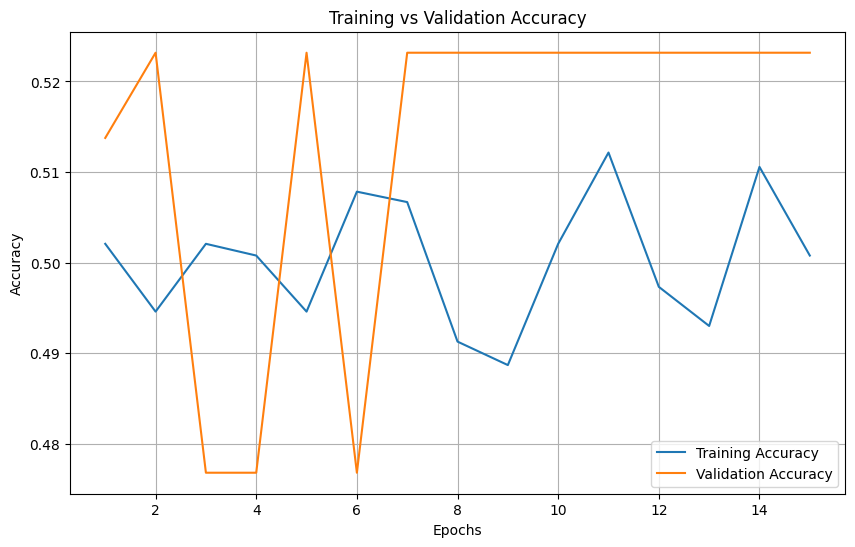

In [79]:
import matplotlib.pyplot as plt

# Plot training vs validation accuracy
def plot_training_history(history):
    # Extract accuracy values from the history object
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(train_acc) + 1)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

# Call the function to plot training vs validation accuracy
plot_training_history(history)


In [80]:
# Convert the 'code' to 'name' mapping in hero_mapping_df to a dictionary
hero_code_to_name = hero_mapping_df.set_index('code')['name'].to_dict()

# Function to decode a one-hot encoded snapshot back to words
def decode_one_hot_snapshot(one_hot_snapshot, index_to_word):
    return [index_to_word[idx] for idx in np.argmax(one_hot_snapshot, axis=1)]

# Function to replace hero codes with hero names in the decoded snapshot
def decode_snapshot_with_names(snapshot, hero_code_to_name):
    return [hero_code_to_name.get(word, word) for word in snapshot]

# Function to format the decoded snapshot into lines with 4 words each, excluding 'Null'
def format_decoded_snapshot(snapshot):
    filtered_snapshot = [word for word in snapshot if word != 'Null']
    lines = [' '.join(filtered_snapshot[i:i+4]) for i in range(0, len(filtered_snapshot), 4)]
    return '\n'.join(lines)

# Visualise the first few snapshots, predicted win probabilities, and actual outcomes
def visualise_win_probabilities_with_names(snapshots, targets, win_probabilities, index_to_word, hero_code_to_name, num_samples=5):
    for i in range(min(num_samples, len(snapshots))):
        # Decode the one-hot encoded snapshot to words
        decoded_snapshot = decode_one_hot_snapshot(snapshots[i], index_to_word)

        # Replace hero codes with hero names
        decoded_snapshot_with_names = decode_snapshot_with_names(decoded_snapshot, hero_code_to_name)

        # Format the decoded snapshot for better readability
        formatted_snapshot = format_decoded_snapshot(decoded_snapshot_with_names)

        # Predicted win probability
        win_prob = win_probabilities[i][0]
        actual_outcome = targets[i]

        # Display the snapshot, win probability, and actual outcome
        print(f"Snapshot {i+1}:\n{formatted_snapshot}")
        print(f"\nPredicted Win Probability: {win_prob:.2f}")
        print(f"Actual Match Outcome: {'Win' if actual_outcome == 1 else 'Loss'}")
        print("=" * 50)

# Get win probabilities for the test set
win_probabilities = model.predict(X_test)

# Call the visualisation function to check the first 5 samples
visualise_win_probabilities_with_names(X_test, y_test, win_probabilities, index_to_word, hero_code_to_name, num_samples=30)


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Snapshot 1:
Ban 0 team_A New Moon Luna
Ban 0 team_A Death Dealer Ray
Ban 0 team_B Harsetti
Ban 0 team_B Zio
Pick 1 team_A Sea Phantom Politis

Predicted Win Probability: 0.48
Actual Match Outcome: Win
Snapshot 2:
Ban 0 team_A New Moon Luna
Ban 0 team_A Death Dealer Ray
Ban 0 team_B Harsetti
Ban 0 team_B Zio
Pick 1 team_A Sea Phantom Politis
Pick 2 team_B Afternoon Soak Flan

Predicted Win Probability: 0.48
Actual Match Outcome: Win
Snapshot 3:
Ban 0 team_A New Moon Luna
Ban 0 team_A Death Dealer Ray
Ban 0 team_B Harsetti
Ban 0 team_B Zio
Pick 1 team_A Sea Phantom Politis
Pick 2 team_B Afternoon Soak Flan
Pick 3 team_B Veronica

Predicted Win Probability: 0.48
Actual Match Outcome: Win
Snapshot 4:
Ban 0 team_A New Moon Luna
Ban 0 team_A Death Dealer Ray
Ban 0 team_B Harsetti
Ban 0 team_B Zio
Pick 1 team_A Sea Phantom Politis
Pick 2 team_B Afternoon Soak Flan
Pick 3 team_B Veronica
Pick 4 team_A Empyrean Ilynav

Predicted Win Probability: 0.48
Actu